# JPX — Change Point Detection (레짐 전환 탐지)

주가 시계열에서 '가격 레벨/변동성/추세'가 크게 바뀌는 시점을 찾습니다.
원본(`code/jpx/change_point.ipynb`)의 두 가지 방식을 `src/change_point.py` 모듈로 정리해 재사용합니다.

## 구성
1. 데이터 로드
2. 단순 버전 — `ruptures.Pelt` (`analyze_stock_pelt`)
3. 고급 버전 — 커스텀 강건 탐지기 (`detect_change_points`)
4. 여러 종목 비교
5. 결론

## 0. 환경 세팅

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import jpx_loader, change_point as cp

print("imports OK")

imports OK


## 1. 데이터 로드

In [2]:
prices = jpx_loader.load_stock_prices("train")
print("shape:", prices.shape)

# 대표 종목 몇 개.
codes = [1301, 7203, 9984, 6758]  # 니쓰이·토요타·소프트뱅크·소니
for code in codes:
    s = cp.get_stock_series(prices, code)
    print(f"{code}: {len(s)} rows, {s.index.min().date()} ~ {s.index.max().date()}")

shape: (2332531, 12)
1301: 1202 rows, 2017-01-04 ~ 2021-12-03
7203: 1202 rows, 2017-01-04 ~ 2021-12-03
9984: 1202 rows, 2017-01-04 ~ 2021-12-03
6758: 1202 rows, 2017-01-04 ~ 2021-12-03


## 2. 단순 버전 — `ruptures.Pelt`

`analyze_stock_pelt`은 `Close.pct_change` → 스무딩 → PELT(rbf cost)를 한 번에 수행하고 플롯도 그려 리턴합니다.

/home/lacid/projects/toy/src/change_point.py:116: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  series = temp["Close"].pct_change().dropna()


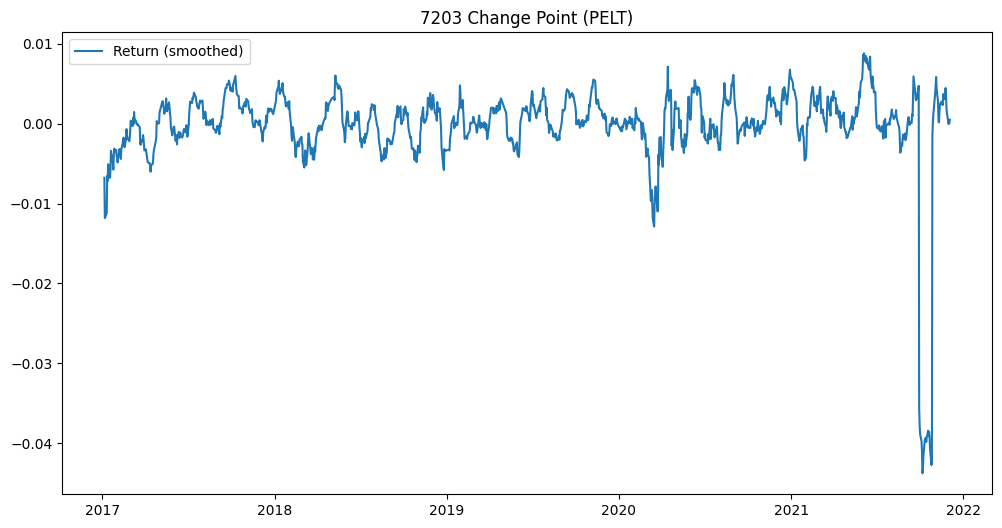

탐지된 변화점 수: 0  (마지막은 끝점)


In [3]:
code = 7203  # 토요타
change_idx = cp.analyze_stock_pelt(prices, code=code, pen=100, window=20)
plt.show()
print(f"탐지된 변화점 수: {len(change_idx) - 1}  (마지막은 끝점)")

### 민감도 비교 — penalty 튜닝

penalty가 작을수록 더 많은 변화점을 찾습니다.

/tmp/ipykernel_292850/3806372271.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = series.pct_change().dropna()


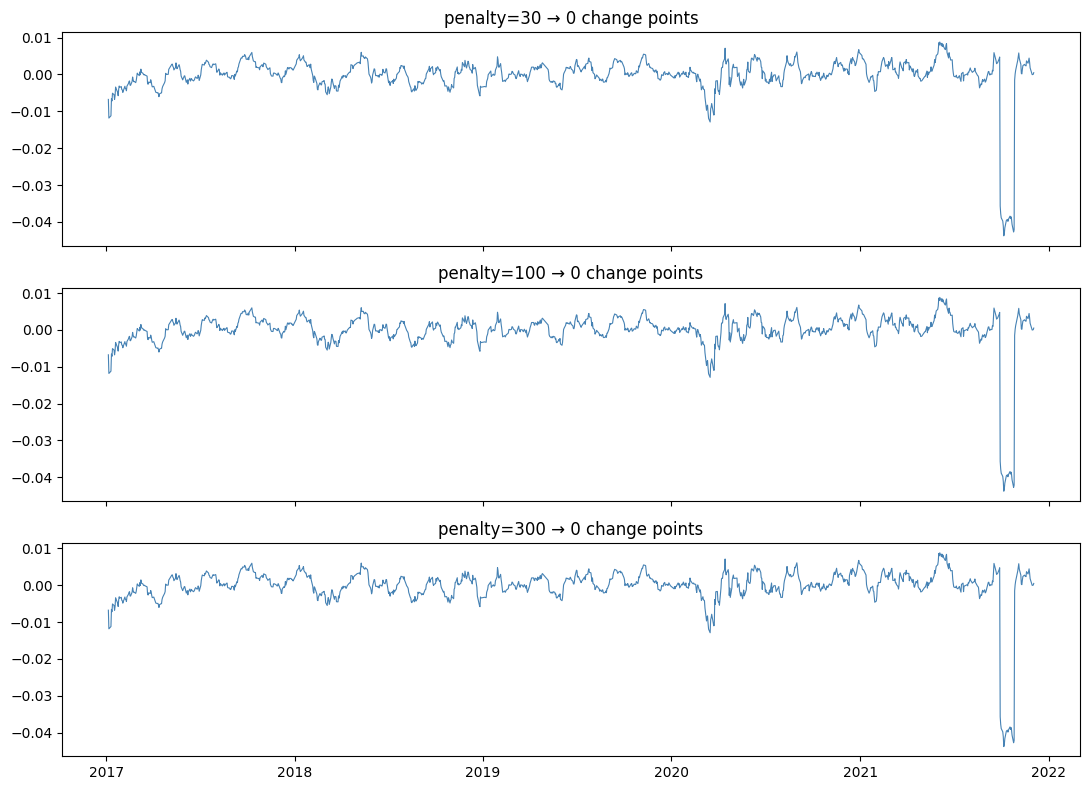

In [4]:
# 내부 헬퍼들을 직접 조합해 플롯 3개를 한 figure에 비교.
series = cp.get_stock_series(prices, code)["Close"]
returns = series.pct_change().dropna()
smoothed = cp.smooth_series(returns, window=20)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, pen in zip(axes, [30, 100, 300]):
    points = cp.pelt_change_points(smoothed, model="rbf", pen=pen)
    ax.plot(smoothed.index, smoothed.values, color="steelblue", lw=0.8)
    for p in points:
        if p < len(smoothed):
            ax.axvline(smoothed.index[p], color="crimson", lw=0.7, alpha=0.7)
    ax.set_title(f"penalty={pen} → {len(points) - 1} change points")
fig.tight_layout()
plt.show()

## 3. 고급 버전 — 강건 복합 탐지기

`cp.detect_change_points`는 세 신호를 합산합니다:
- **Level shift** — 좌·우 window의 median 차이
- **Volatility shift** — 좌·우 window의 MAD 차이
- **Trend shift** — 좌·우 window의 OLS 기울기 차이

입력으로 단일 시리즈 또는 DataFrame을 받고, 반환은 dict (`change_points`, `score`, `threshold`, `transform_used`, ...).

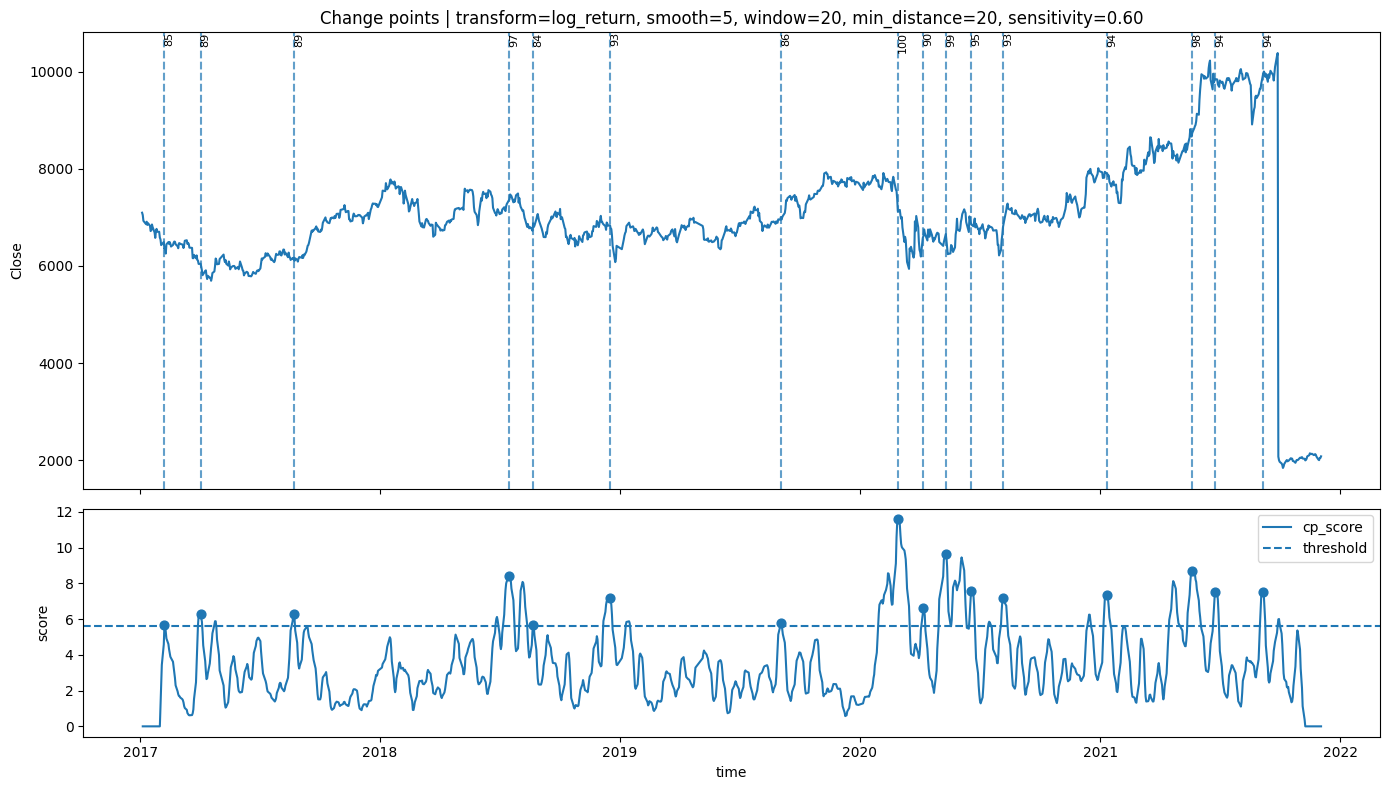

변화점 수: 16, transform=log_return, threshold=5.631


,proc_pos,time,raw_score,z_strength,strength_0_100,level_shift,volatility_shift,trend_shift
0,22,2017-02-07,5.682015,2.041080,84.582257,2.222239,0.806863,4.023589
1,60,2017-04-03,6.273360,2.517959,88.888889,0.786311,1.179439,6.417504
2,157,2017-08-23,6.291286,2.532415,89.061154,1.450564,0.440104,6.082885
3,377,2018-07-17,8.384931,4.220793,97.416021,0.529828,0.970262,9.352392
4,403,2018-08-22,5.647252,2.013046,84.065461,1.992050,0.873478,5.303898
5,482,2018-12-17,7.189743,3.256957,93.367786,0.606542,1.363911,7.051947
6,652,2019-09-03,5.800470,2.136605,85.615848,1.313763,0.574486,5.348357
7,768,2020-02-28,11.605399,6.817875,100.000000,1.596431,2.735955,10.873160
8,794,2020-04-07,6.615774,2.794092,90.180879,2.260125,3.169432,4.018954
9,814,2020-05-11,9.653846,5.244084,99.224806,2.036855,1.174378,9.337935


In [5]:
stock = cp.get_stock_series(prices, code)

# transform='log_return'은 가격 스케일 효과를 제거해 수익률 기반으로 비교.
out = cp.detect_change_points(
    stock, value_cols="Close", transform="log_return",
    smooth=5, window=20, min_distance=20,
    sensitivity=0.6, plot=True,
)
plt.show()
print(f"변화점 수: {len(out['change_points'])}, transform={out['transform_used']}, threshold={out['threshold']:.3f}")
out["change_points"].head(10)

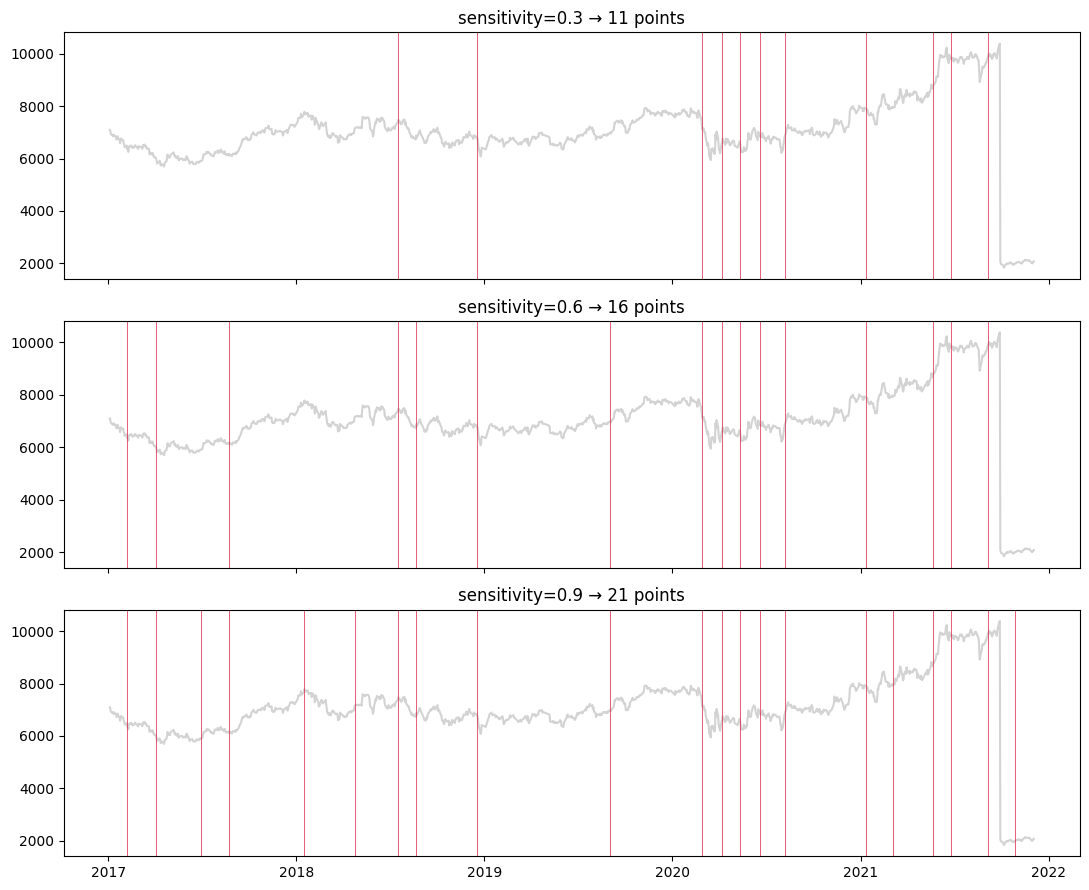

In [6]:
# sensitivity 비교 (같은 데이터에 대해).
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, sens in zip(axes, [0.3, 0.6, 0.9]):
    r = cp.detect_change_points(
        stock, value_cols="Close", transform="log_return",
        smooth=5, window=20, min_distance=20,
        sensitivity=sens, plot=False,
    )
    ax.plot(stock.index, stock["Close"], color="lightgray")
    for t in r["change_points"]["time"]:
        ax.axvline(t, color="crimson", lw=0.7, alpha=0.7)
    ax.set_title(f"sensitivity={sens} → {len(r['change_points'])} points")
fig.tight_layout()
plt.show()

## 4. 여러 종목 비교

같은 파라미터로 4개 종목을 한번에 탐지 — 시장 공통 이벤트(COVID shock 등)가 비슷한 날짜에 잡히는지 확인.

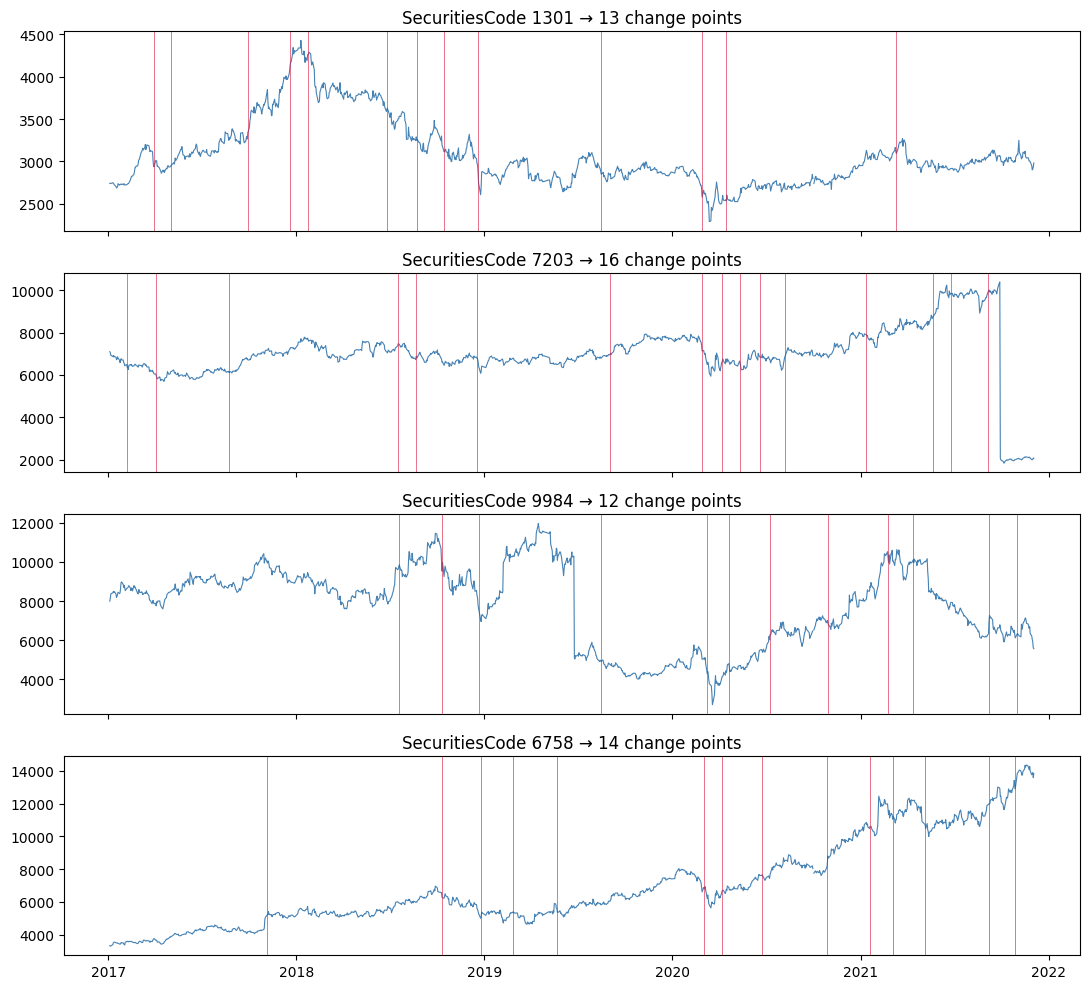

In [7]:
fig, axes = plt.subplots(len(codes), 1, figsize=(11, 2.5 * len(codes)), sharex=True)
for ax, c in zip(axes, codes):
    s = cp.get_stock_series(prices, c)
    r = cp.detect_change_points(
        s, value_cols="Close", transform="log_return",
        smooth=5, window=20, min_distance=20,
        sensitivity=0.6, plot=False,
    )
    ax.plot(s.index, s["Close"], color="steelblue", lw=0.8)
    for t in r["change_points"]["time"]:
        ax.axvline(t, color="crimson", lw=0.6, alpha=0.7)
    ax.set_title(f"SecuritiesCode {c} → {len(r['change_points'])} change points")
fig.tight_layout()
plt.show()

## 결론

- **단순 PELT**는 직관적이고 빠르지만 (`rbf` 커널에서도) 주로 분산 레벨 변화에 민감하다. 파라미터 `pen`이 핵심 튜닝 노브.
- **강건 복합 탐지기**는 level + volatility + trend 세 축을 모두 본다. MAD 스케일링 덕분에 종목별 분산 차이에 덜 민감하고, 이상치 클립 덕분에 점프 이벤트 하나에 잡아먹히지 않는다.
- 탐지된 변화점은 피처(레짐 더미, 최근 변화점으로부터의 경과일)로 모델에 투입하거나, 시각적 레짐 구간 분리에 쓸 수 있다.
- 파라미터(`window`, `min_distance`, `sensitivity`)는 종목의 거래 빈도·노이즈 수준에 따라 튜닝 필요.